# Oasis Infobyte Internship

## Level 2 - Task 1

# House Price Prediction using Machine Learning

## Objective

The objective of this project is to build a machine learning model that predicts house prices based on various features such as area, number of bedrooms, bathrooms, and other property characteristics. This project demonstrates the application of data preprocessing, exploratory data analysis, feature engineering, and regression techniques to solve a real-world prediction problem.

## Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Read the Dataset

In [5]:
df = pd.read_csv("Housing.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Understand the Dataset

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Observation

- The dataset contains **21,613 rows** and **21 columns**.
- There are **no missing (null) values** in the dataset.
- Most columns are of numeric data type (integer and float), while the **date** column is of object type.
- The dataset is clean and ready for further exploratory data analysis and preprocessing.

## Statistical Summary

In [7]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580306e+09,5.400886e+05,3.370795,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876570e+09,3.671268e+05,0.930105,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Observation

- The average house price is approximately **540,089**.
- Most houses have **3 to 4 bedrooms** and **2 bathrooms**.
- The average living area is around **2,080 square feet**.
- Some features such as **price, bedrooms, sqft_living, and sqft_lot** have a wide range of values, indicating the possible presence of outliers.
- The dataset contains sufficient numerical features for building a house price prediction model.

## Check Missing Values

In [8]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


### Observation

- All columns contain **0 missing values**.
- The dataset is complete and does not require missing value treatment.
- We can proceed directly with duplicate value checking and exploratory data analysis.

## Check Duplicate Values

In [9]:
df.duplicated().sum()

np.int64(0)

### Observation

- The dataset contains **0 duplicate records**.
- No duplicate rows need to be removed.
- The dataset is clean and ready for Exploratory Data Analysis (EDA).

## Dataset Shape

In [10]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 21613
Number of Columns : 21


### Observation

- The dataset contains **21,613 rows** and **21 columns**.
- The dataset is complete with no missing values or duplicate records.
- It is ready for Exploratory Data Analysis (EDA) and machine learning model development.

# Exploratory Data Analysis (EDA)

## Distribution of House Prices

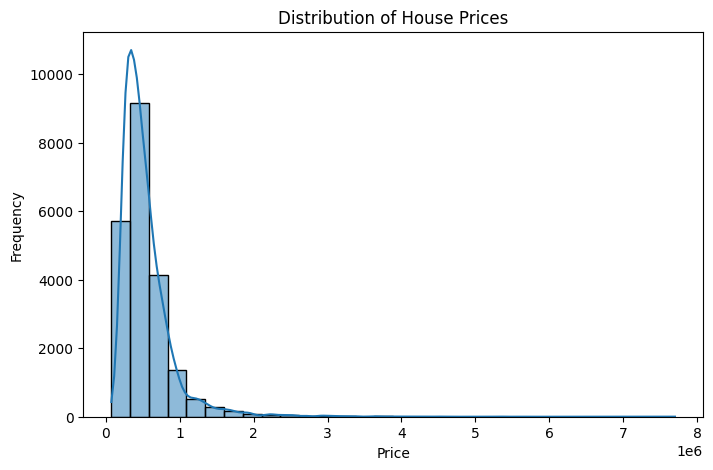

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most houses are concentrated in the lower to middle price range.
- The distribution of house prices is **positively (right) skewed**.
- A few houses have extremely high prices, indicating the presence of **outliers**.
- The target variable (price) is not normally distributed.

## Correlation Heatmap

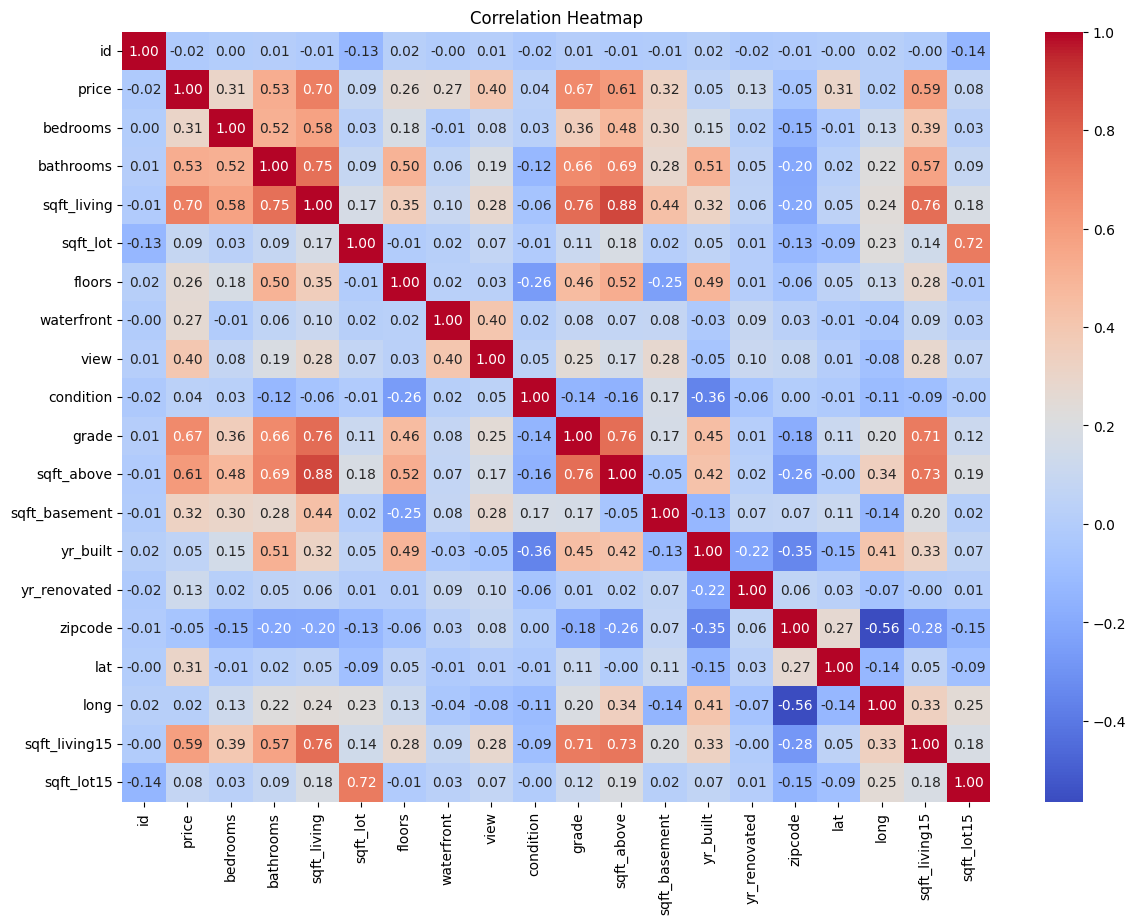

In [12]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observation

- The heatmap shows the correlation between numerical features.
- **sqft_living**, **grade**, **sqft_above**, **sqft_living15**, and **bathrooms** have a strong positive correlation with house price.
- **Bedrooms** show a moderate positive correlation with price.
- The heatmap helps identify the most important features for predicting house prices.

## House Price vs Living Area

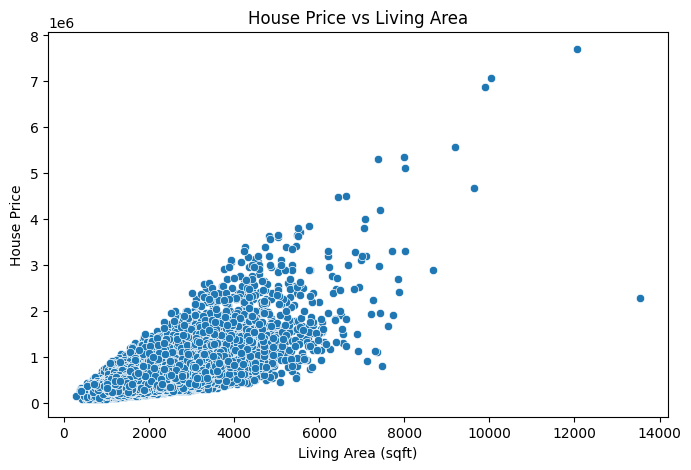

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["sqft_living"], y=df["price"])

plt.title("House Price vs Living Area")
plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")

plt.show()

### Observation

- The scatter plot shows a positive relationship between living area and house price.
- As the living area increases, the house price generally increases.
- The data points are scattered because house prices are also influenced by other factors such as location, condition, grade, and amenities.
- Living area is an important feature for predicting house prices.

## Box Plot of House Prices

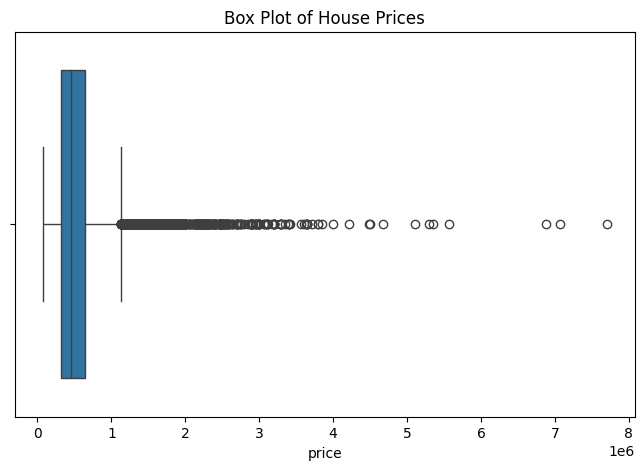

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.title("Box Plot of House Prices")

plt.show()

### Observation

- The box plot indicates the presence of several high-price outliers.
- Most house prices are concentrated within the central range, while a few houses have exceptionally high prices.
- These outliers represent luxury or premium houses and may influence the regression model.
- The box plot confirms the right-skewed distribution observed in the histogram.

# Data Preprocessing

## Select Features and Target Variable

In [16]:
X = df.drop(["price", "id", "date"], axis=1)

y = df["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (21613, 18)
Target Shape: (21613,)


### Observation

- The input features (**X**) contain **18 columns** after removing the **price**, **id**, and **date** columns.
- The target variable (**y**) contains the **house prices** to be predicted.
- The dataset is now ready to be split into training and testing sets.

## Split the Dataset into Training and Testing Sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (17290, 18)
Testing Features: (4323, 18)
Training Target: (17290,)
Testing Target: (4323,)


### Observation

- The dataset was successfully split into training and testing sets.
- **80%** of the data (17,290 records) was used for training.
- **20%** of the data (4,323 records) was used for testing.
- The testing dataset will be used to evaluate the model's performance on unseen data.

## Train the Linear Regression Model

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


### Observation

- The Linear Regression model was successfully trained using the training dataset.
- The model learned the relationship between the input features and house prices.
- The trained model is now ready to predict house prices for unseen data.

## Predict House Prices

In [19]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[ 461210.48000615  752445.51429521 1238489.95153704 1662424.61240977
  734887.82894384]


### Observation

- The trained Linear Regression model successfully predicted house prices for the test dataset.
- The output displays the predicted prices of the first five houses.
- These predictions will be compared with the actual house prices to evaluate the model's performance.

## Compare Actual and Predicted Prices

In [20]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head()

,Actual Price,Predicted Price
0,365000.0,4.612105e+05
1,865000.0,7.524455e+05
2,1038000.0,1.238490e+06
3,1490000.0,1.662425e+06
4,711000.0,7.348878e+05


### Observation

- The table compares the actual house prices with the predicted prices.
- The predicted values are reasonably close to the actual values, although some differences exist.
- A detailed evaluation using performance metrics is required to measure the overall accuracy of the model.

## Model Evaluation

In [21]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 45173027114.56454
R² Score: 0.7011905706891326


### Observation

- The Mean Squared Error (MSE) is **45,173,027,114.56**, representing the average squared prediction error.
- The model achieved an **R² Score of 0.7012**, indicating that it explains approximately **70.12%** of the variation in house prices.
- The Linear Regression model demonstrates good predictive performance on the test dataset.

## Predict House Price for a New House

In [22]:
new_house = [[
    3,          # bedrooms
    2,          # bathrooms
    1800,       # sqft_living
    5000,       # sqft_lot
    2,          # floors
    0,          # waterfront
    0,          # view
    3,          # condition
    8,          # grade
    1800,       # sqft_above
    0,          # sqft_basement
    1998,       # yr_built
    0,          # yr_renovated
    98052,      # zipcode
    47.60,      # latitude
    -122.15,    # longitude
    1850,       # sqft_living15
    5200        # sqft_lot15
]]

predicted_price = model.predict(new_house)

print("Predicted House Price: ${:,.2f}".format(predicted_price[0]))

Predicted House Price: $465,428.54


### Observation

- The trained Linear Regression model successfully predicted the price of a new house using user-provided features.
- This demonstrates that the model can be used to estimate house prices for unseen data.
- Such a prediction system can be integrated into real-world applications like real estate websites and property valuation systems.

# Conclusion

This project successfully developed a **House Price Prediction** model using **Linear Regression**.

The dataset was explored through Exploratory Data Analysis (EDA), including distribution analysis, correlation analysis, scatter plots, and box plots. Data preprocessing involved selecting relevant features and splitting the dataset into training and testing sets.

The Linear Regression model was trained and evaluated using **Mean Squared Error (MSE)** and **R² Score**. The model achieved an **R² Score of 0.7012**, indicating that it explains approximately **70% of the variation** in house prices.

Finally, the trained model was used to predict the price of a new house using user-provided input features, demonstrating its ability to estimate house prices for unseen data.

Overall, this project demonstrates the practical application of machine learning for real-world house price prediction and can serve as a foundation for developing real estate price prediction systems.